## *Import Library*

In [1]:
# Library untuk pengolahan data
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB

# Library evaluasi model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## *Data Understanding*

#### *Load Dataset*

In [2]:
# Membaca dataset
df = pd.read_csv("D:\liver-disease-classification\data\indian_liver_patient.csv")

# Menampilkan 5 data pertama
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Kategori
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


#### *Melihat Ukuran Dataset*

In [3]:
# Menampilkan jumlah baris dan kolom
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 579
Jumlah kolom : 11


#### *Melihat Informasi Dataset*

In [4]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         579 non-null    int64  
 1   Gender                      579 non-null    int64  
 2   Total_Bilirubin             579 non-null    float64
 3   Direct_Bilirubin            579 non-null    float64
 4   Alkaline_Phosphotase        579 non-null    int64  
 5   Alamine_Aminotransferase    579 non-null    int64  
 6   Aspartate_Aminotransferase  579 non-null    int64  
 7   Total_Protiens              579 non-null    float64
 8   Albumin                     579 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Kategori                    579 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 49.9 KB


### *5. Melihat Nama Kolom*

In [5]:
# Menampilkan nama-nama kolom
print("Nama kolom:")
print(df.columns.tolist())

Nama kolom:
['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Kategori']


## *Data Cleaning*

#### *Mengecek Missing Value*

In [6]:
# Mengecek jumlah missing value pada setiap kolom
missing_values = df.isnull().sum()

display(missing_values)

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Kategori                      0
dtype: int64

In [7]:
if missing_values.sum() == 0:
    print("Dataset tidak memiliki missing value.")
else:
    print("Dataset memiliki missing value.")

Dataset tidak memiliki missing value.


#### *Mengecek Data Duplikat*

In [8]:
# Mengecek jumlah data duplikat
duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 13


In [9]:
# Menampilkan data yang terduplikasi
df[df.duplicated()]

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Kategori
19,40,0,0.9,0.3,293,232,245,6.8,3.1,0.80,1
26,34,1,4.1,2.0,289,875,731,5.0,2.7,1.10,1
34,38,0,2.6,1.2,410,59,57,5.6,3.0,0.80,2
55,42,1,8.9,4.5,272,31,61,5.8,2.0,0.50,1
62,58,1,1.0,0.5,158,37,43,7.2,3.6,1.00,1
106,36,1,5.3,2.3,145,32,92,5.1,2.6,1.00,2
108,36,1,0.8,0.2,158,29,39,6.0,2.2,0.50,2
138,18,1,0.8,0.2,282,72,140,5.5,2.5,0.80,1
143,30,1,1.6,0.4,332,84,139,5.6,2.7,0.90,1
158,72,1,0.7,0.1,196,20,35,5.8,2.0,0.50,1


#### *Menghapus Data Duplikat*

In [10]:
# Menghapus data duplikat
df = df.drop_duplicates().reset_index(drop=True)

In [11]:
print("Jumlah data setelah menghapus duplikat:", len(df))
print("Jumlah duplikat setelah cleaning:", df.duplicated().sum())

Jumlah data setelah menghapus duplikat: 566
Jumlah duplikat setelah cleaning: 0


#### *Melihat Statistik Deskriptif*

In [12]:
# Statistik deskriptif data numerik
df.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Kategori
count,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000
mean,44.886926,0.756184,3.338869,1.505830,292.567138,80.143110,109.892226,6.494876,3.145583,0.948004,1.286219
std,16.274893,0.429763,6.286728,2.841485,245.936559,182.044881,291.841897,1.087512,0.795745,0.319635,0.452393
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,1.000000,0.800000,0.200000,176.000000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,1.000000,0.300000,208.000000,35.000000,41.000000,6.600000,3.100000,0.950000,1.000000
75%,58.000000,1.000000,2.600000,1.300000,298.000000,60.750000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


#### *Melihat Distribusi Kategori*

In [13]:
# Melihat jumlah masing-masing kategori
kategori_count = df["Kategori"].value_counts()

display(kategori_count)

Kategori
1    404
2    162
Name: count, dtype: int64

In [14]:
# Persentase masing-masing kategori
kategori_percentage = df["Kategori"].value_counts(normalize=True) * 100

display(kategori_percentage.round(2))

Kategori
1    71.38
2    28.62
Name: proportion, dtype: float64

#### *Visualisasi Distribusi Kategori*

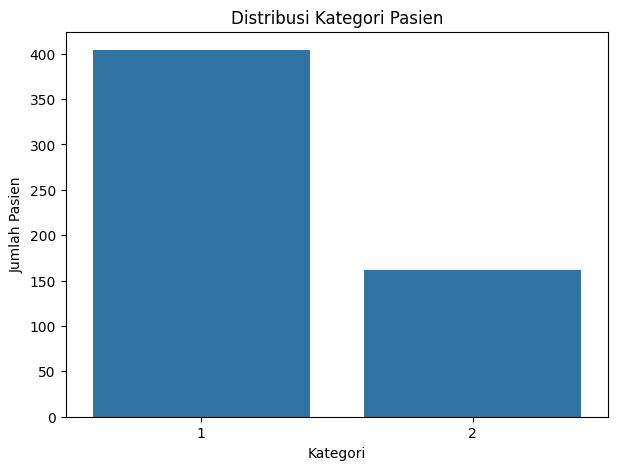

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Kategori")

plt.title("Distribusi Kategori Pasien")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Pasien")

plt.show()

#### *Melihat Distribusi Gender*

In [16]:
print("Distribusi Gender:")
display(df["Gender"].value_counts())

Distribusi Gender:


Gender
1    428
0    138
Name: count, dtype: int64

## *Exploratory Data Analysis*

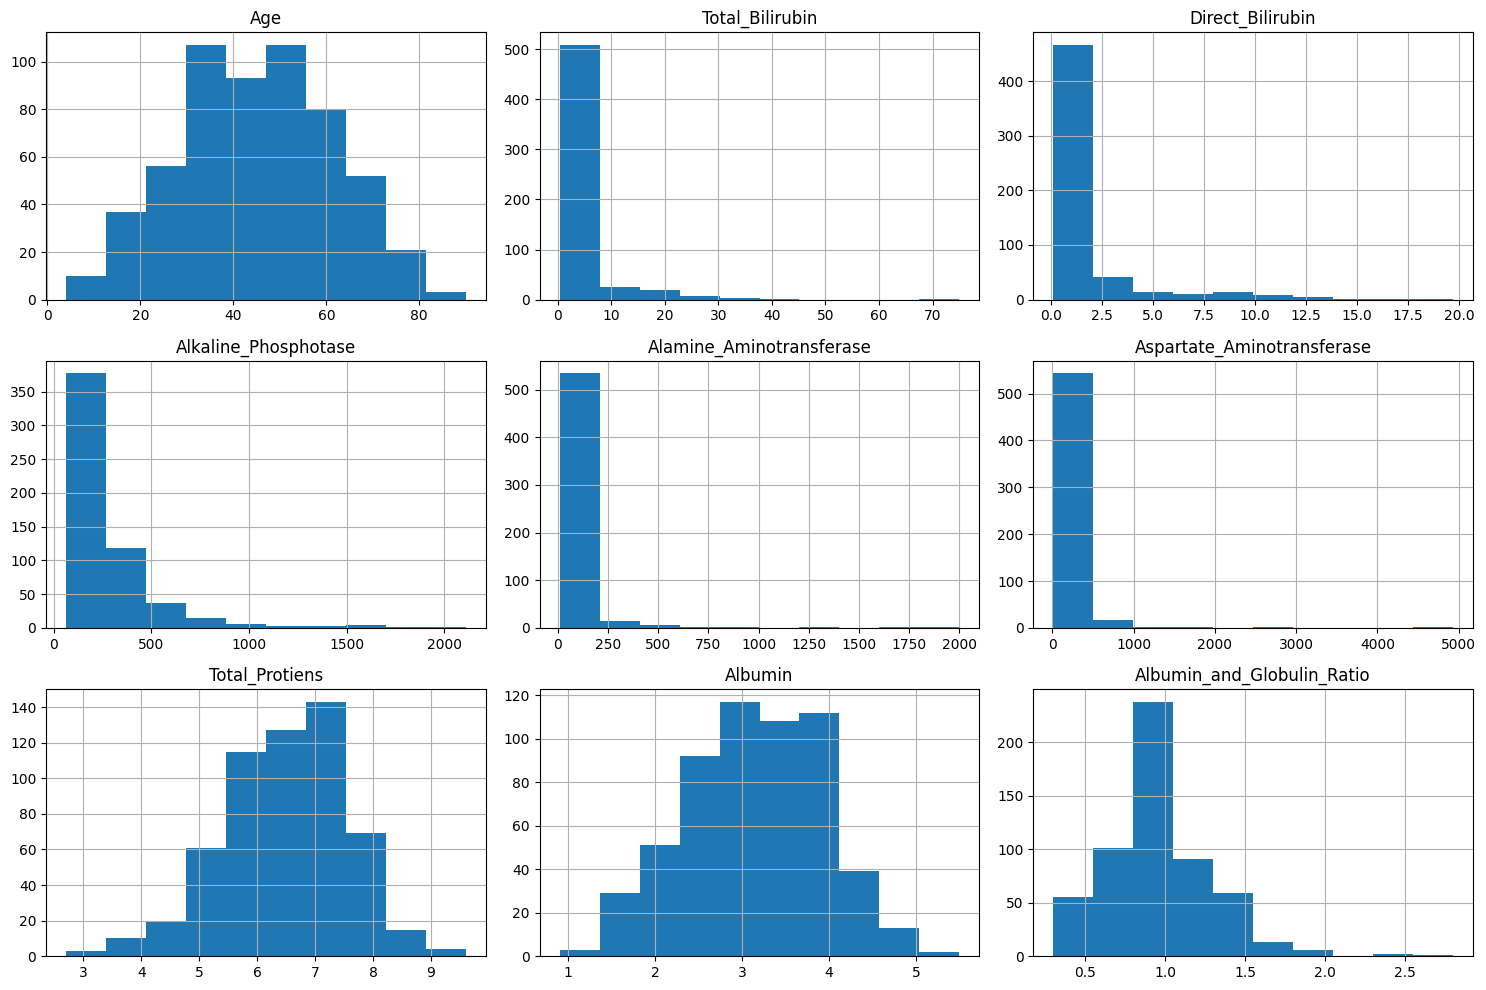

In [17]:
# Memilih kolom fitur numerik
numeric_features = [
    "Age",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio"
]

# Membuat histogram
df[numeric_features].hist(figsize=(15, 10))

plt.tight_layout()
plt.show()

### *14. Melihat Korelasi Antar-Fitur*

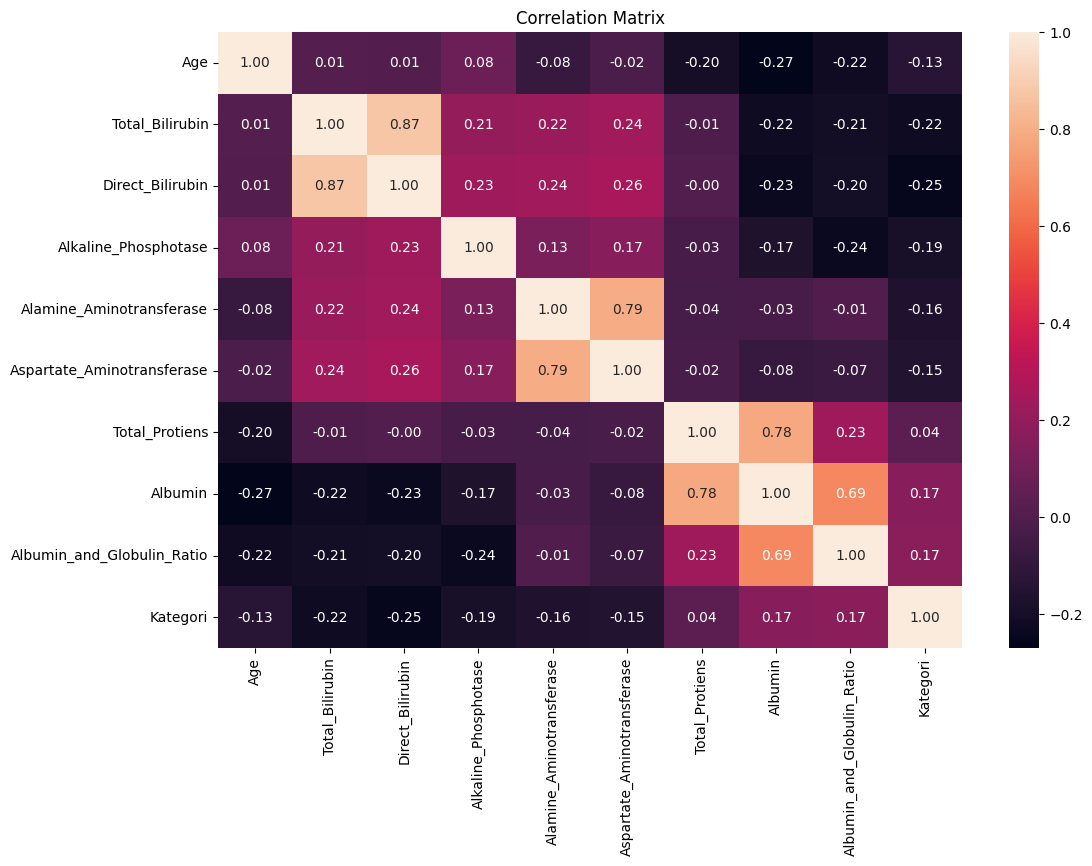

In [18]:
plt.figure(figsize=(12, 8))

correlation = df[numeric_features + ["Kategori"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## *Preprocessing* 

#### *Menentukan Feature dan Target*

In [19]:
features = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio"
]

# Feature
X = df[features].copy()

# Target / label
y = df["Kategori"].copy()

print("Jumlah feature:", X.shape[1])
print("Jumlah data:", X.shape[0])

Jumlah feature: 10
Jumlah data: 566


In [20]:
X.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40


In [21]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Kategori, dtype: int64

#### *Cek Tipe Data Feature*

In [22]:
X.dtypes

Age                             int64
Gender                          int64
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Protiens                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
dtype: object

In [23]:
X.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
dtype: int64

#### *Train-Test Split*

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

In [25]:
print("Jumlah data training :", X_train.shape[0])
print("Jumlah data testing  :", X_test.shape[0])

Jumlah data training : 452
Jumlah data testing  : 114


#### *Normalisasi dengan Min-Max Scaler* 

In [27]:
scaler = MinMaxScaler()

In [28]:
X_train_scaled = scaler.fit_transform(X_train)

In [29]:
X_test_scaled = scaler.transform(X_test)

In [30]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [31]:
X_train_scaled.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
286,0.534884,0.0,0.017426,0.025510,0.179287,0.009045,0.004270,0.594203,0.565217,0.28
16,0.395349,1.0,0.018767,0.035714,0.136297,0.079397,0.087434,0.710145,0.760870,0.40
80,0.116279,1.0,0.013405,0.020408,0.100635,0.024121,0.006913,0.579710,0.652174,0.44
331,0.767442,1.0,0.012064,0.015306,0.144113,0.004523,0.000610,0.492754,0.413043,0.20
272,0.534884,0.0,0.008043,0.020408,0.085979,0.003015,0.005693,0.695652,0.608696,0.24


## *Modeling*

#### *Gaussian Naive Bayes*

In [32]:
# Membuat model Gaussian Naive Bayes
model = GaussianNB()

In [33]:
# Melatih model menggunakan data training
model.fit(X_train_scaled, y_train)

GaussianNB()

### *Melakukan Prediksi*

In [34]:
# Melakukan prediksi terhadap data testing
y_pred = model.predict(X_test_scaled)

# Menampilkan beberapa hasil prediksi
print("Hasil prediksi:")
print(y_pred[:10])

Hasil prediksi:
[2 2 2 2 2 2 2 2 1 1]


In [35]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,2,2
1,1,2
2,1,2
3,2,2
4,1,2
5,2,2
6,2,2
7,2,2
8,1,1
9,1,1


### *Menghitung Accuracy*

In [36]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", round(accuracy * 100, 2), "%")


Accuracy: 0.5263157894736842
Accuracy (%): 52.63 %


### *Precision, Recall, dan F1-Score*

In [37]:
precision = precision_score(
    y_test,
    y_pred,
    pos_label=1
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1
)

print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Precision: 0.9655
Recall   : 0.3457
F1-Score : 0.5091


### *Classification Report*

In [38]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.35      0.51        81
           2       0.38      0.97      0.54        33

    accuracy                           0.53       114
   macro avg       0.67      0.66      0.53       114
weighted avg       0.80      0.53      0.52       114



### *Confusion Matrix*

In [39]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[28 53]
 [ 1 32]]


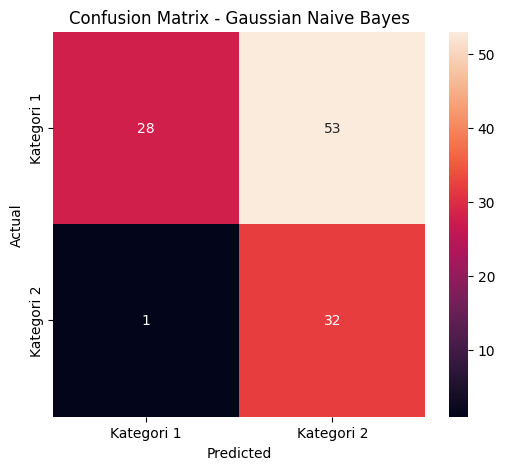

In [40]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Kategori 1", "Kategori 2"],
    yticklabels=["Kategori 1", "Kategori 2"]
)

plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### *Ringkasan Hasil Model*

In [41]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results

,Metric,Score
0,Accuracy,0.526316
1,Precision,0.965517
2,Recall,0.345679
3,F1-Score,0.509091


In [42]:
results_percentage = results.copy()

results_percentage["Score"] = (
    results_percentage["Score"] * 100
).round(2)

results_percentage

,Metric,Score
0,Accuracy,52.63
1,Precision,96.55
2,Recall,34.57
3,F1-Score,50.91


## *Model Comparison*

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [44]:
models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=1
    ),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [45]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

In [46]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
1,Logistic Regression,0.710526,0.710526,1.000000,0.830769
5,SVM,0.710526,0.710526,1.000000,0.830769
2,Decision Tree,0.666667,0.759036,0.777778,0.768293
3,Random Forest,0.640351,0.717391,0.814815,0.763006
4,KNN,0.622807,0.711111,0.790123,0.748538
0,Gaussian Naive Bayes,0.526316,0.965517,0.345679,0.509091


In [47]:
results_df["Accuracy"] = (
    results_df["Accuracy"] * 100
).round(2)

results_df["Precision"] = (
    results_df["Precision"] * 100
).round(2)

results_df["Recall"] = (
    results_df["Recall"] * 100
).round(2)

results_df["F1-Score"] = (
    results_df["F1-Score"] * 100
).round(2)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
1,Logistic Regression,71.05,71.05,100.00,83.08
5,SVM,71.05,71.05,100.00,83.08
2,Decision Tree,66.67,75.90,77.78,76.83
3,Random Forest,64.04,71.74,81.48,76.30
4,KNN,62.28,71.11,79.01,74.85
0,Gaussian Naive Bayes,52.63,96.55,34.57,50.91


## *Hyperparameter Tuning*

### *Logistic Regression — tuning*

In [48]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(
    max_iter=1000,
    random_state=1
)

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(
    estimator=logistic,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)

Best Parameters: {'C': 100, 'solver': 'liblinear'}
Best CV Accuracy: 0.7300610500610502


In [49]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Test Precision:", precision_score(y_test, y_pred_lr, pos_label=1))
print("Test Recall:", recall_score(y_test, y_pred_lr, pos_label=1))
print("Test F1:", f1_score(y_test, y_pred_lr, pos_label=1))

Test Accuracy: 0.7105263157894737
Test Precision: 0.7352941176470589
Test Recall: 0.9259259259259259
Test F1: 0.819672131147541


### *SVM — tuning*

In [50]:
from sklearn.svm import SVC

svm = SVC()

param_grid_svm = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV Accuracy:", grid_svm.best_score_)

Best Parameters: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy: 0.7146031746031747


In [51]:
best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Test Precision:", precision_score(y_test, y_pred_svm, pos_label=1))
print("Test Recall:", recall_score(y_test, y_pred_svm, pos_label=1))
print("Test F1:", f1_score(y_test, y_pred_svm, pos_label=1))

Test Accuracy: 0.7105263157894737
Test Precision: 0.7105263157894737
Test Recall: 1.0
Test F1: 0.8307692307692308


### *evaluasi dengan class_weight*

In [52]:
class_weight="balanced"

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr_balanced = LogisticRegression(
    max_iter=1000,
    random_state=1,
    class_weight="balanced"
)

param_grid_lr_balanced = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_lr_balanced = GridSearchCV(
    estimator=lr_balanced,
    param_grid=param_grid_lr_balanced,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr_balanced.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_lr_balanced.best_params_)
print("Best CV Accuracy:", grid_lr_balanced.best_score_)

Best Parameters: {'C': 100, 'solver': 'liblinear'}
Best CV Accuracy: 0.6505738705738706


In [54]:
best_lr_balanced = grid_lr_balanced.best_estimator_

y_pred_lr_balanced = best_lr_balanced.predict(X_test_scaled)

print("Test Accuracy :", accuracy_score(y_test, y_pred_lr_balanced))
print("Test Precision:", precision_score(y_test, y_pred_lr_balanced, pos_label=1))
print("Test Recall   :", recall_score(y_test, y_pred_lr_balanced, pos_label=1))
print("Test F1-Score :", f1_score(y_test, y_pred_lr_balanced, pos_label=1))

Test Accuracy : 0.6228070175438597
Test Precision: 0.88
Test Recall   : 0.5432098765432098
Test F1-Score : 0.6717557251908397


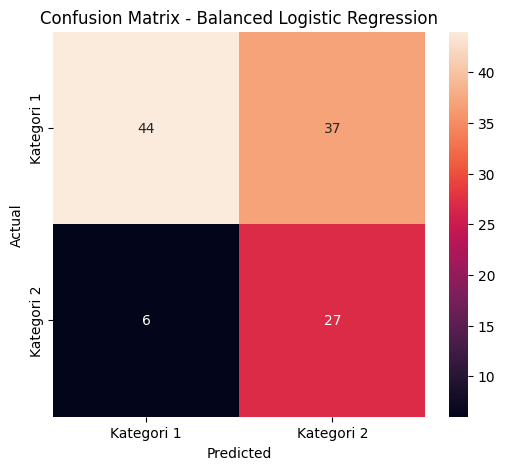

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr_balanced)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Kategori 1", "Kategori 2"],
    yticklabels=["Kategori 1", "Kategori 2"]
)

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## *Final Model*

### *Logistic Regression*

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

# Pipeline preprocessing + model
final_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("classifier", LogisticRegression(
        C=100,
        solver="liblinear",
        max_iter=1000,
        random_state=1
    ))
])

In [57]:
# Training model final
final_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('classifier',
                 LogisticRegression(C=100, max_iter=1000, random_state=1,
                                    solver='liblinear'))])

In [58]:
# Prediksi data testing
y_pred_final = final_model.predict(X_test)

In [59]:
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, pos_label=1)
recall_final = recall_score(y_test, y_pred_final, pos_label=1)
f1_final = f1_score(y_test, y_pred_final, pos_label=1)

print("Final Model: Logistic Regression")
print("--------------------------------")
print(f"Accuracy : {accuracy_final * 100:.2f}%")
print(f"Precision: {precision_final * 100:.2f}%")
print(f"Recall   : {recall_final * 100:.2f}%")
print(f"F1-Score : {f1_final * 100:.2f}%")

Final Model: Logistic Regression
--------------------------------
Accuracy : 71.05%
Precision: 73.53%
Recall   : 92.59%
F1-Score : 81.97%


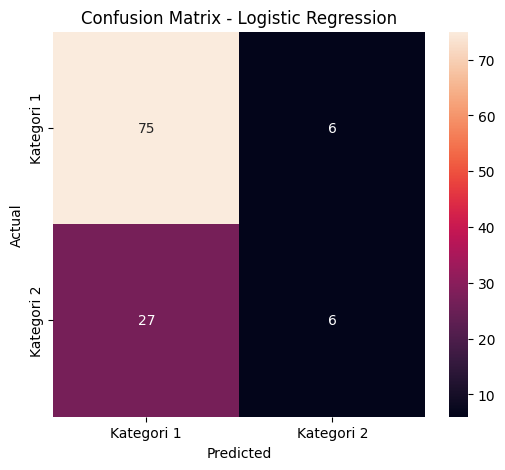

In [60]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Kategori 1", "Kategori 2"],
    yticklabels=["Kategori 1", "Kategori 2"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [61]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           1       0.74      0.93      0.82        81
           2       0.50      0.18      0.27        33

    accuracy                           0.71       114
   macro avg       0.62      0.55      0.54       114
weighted avg       0.67      0.71      0.66       114

